# Autoencoder Variants

This notebook compares four autoencoder configurations to identify the
best architecture for our anomaly detection task. Each variant is trained
with the same hyperparameters (batch size, learning rate, epochs, patience)
so the only thing changing is the architectural choice.

Configurations:
- **Baseline**: [64, 32, 16] vanilla autoencoder
- **Wider**: [128, 64, 32] — more capacity
- **Deeper bottleneck**: [64, 32, 16, 8] — tighter compression
- **Denoising**: same as baseline but with input noise during training

In [2]:
import sys
sys.path.insert(0, '..')

import torch
from torch.utils.data import DataLoader

from src.preprocessing import load_processed
from src.autoencoder import build_autoencoder
from src.train import train_autoencoder
from src.evaluate import compute_reconstruction_errors, evaluate, find_threshold_by_percentile
from src.utils import get_device, set_seed
from src.dataset import NormalOnlyDataset, FraudDataset

device = get_device()
print(f"Device: {device}")

# Load data once, reuse across all experiments
data = load_processed('../data/processed', '../models')
print(f"Train shape: {data['x_train'].shape}")

Device: mps
Train shape: (979379, 16)


In [3]:
def run_experiment(name, model_type='vanilla', hidden_dims=[64,32,16], 
                   dropout=0.2, noise_std=0.1, epochs=60, batch_size=1024):
    """Run one autoencoder configuration. Returns metrics dict."""
    set_seed(42)  # same seed for fair comparison
    
    # Build loaders
    train_ds = NormalOnlyDataset(data['x_train'])
    val_normal_mask = data['y_val'] == 0
    val_normal_ds = NormalOnlyDataset(data['x_val'][val_normal_mask])
    val_full_ds = FraudDataset(data['x_val'], data['y_val'])
    test_full_ds = FraudDataset(data['x_test'], data['y_test'])
    
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    val_normal_loader = DataLoader(val_normal_ds, batch_size=batch_size)
    val_full_loader = DataLoader(val_full_ds, batch_size=batch_size)
    test_full_loader = DataLoader(test_full_ds, batch_size=batch_size)
    
    # Build and train
    model = build_autoencoder(model_type, input_dim=data['input_dim'],
                              hidden_dims=hidden_dims, dropout=dropout,
                              noise_std=noise_std).to(device)
    n_params = sum(p.numel() for p in model.parameters())
    print(f"\n{'='*60}")
    print(f"Experiment: {name}")
    print(f"{'='*60}")
    print(f"Architecture: {hidden_dims}  |  Params: {n_params:,}")
    
    history = train_autoencoder(model, train_loader, val_normal_loader, device,
                                epochs=epochs, patience=10, verbose=False)
    print(f"Trained to epoch {history['best_epoch']}, val_loss={history['best_val_loss']:.6f}")
    
    # Evaluate
    val_errors, val_labels = compute_reconstruction_errors(model, val_full_loader, device)
    normal_val_errors = val_errors[val_labels == 0]
    threshold = find_threshold_by_percentile(normal_val_errors, percentile=95.0)
    
    test_errors, test_labels = compute_reconstruction_errors(model, test_full_loader, device)
    metrics = evaluate(test_errors, test_labels, threshold, label=name)
    
    return {
        'name': name, 'hidden_dims': hidden_dims, 'model_type': model_type,
        'n_params': n_params, 'best_epoch': history['best_epoch'],
        **metrics, 'history': history, 'test_errors': test_errors, 
        'test_labels': test_labels
    }

In [4]:
results = []
results.append(run_experiment('baseline', hidden_dims=[64, 32, 16]))


Experiment: baseline
Architecture: [64, 32, 16]  |  Params: 7,808
Trained to epoch 58, val_loss=0.097427
Threshold at 95.0th percentile of normal errors: 0.227661

  baseline Set Evaluation   (threshold = 0.227661)
              precision    recall  f1-score   support

      Normal     0.8716    0.9503    0.9093    209868
       Fraud     0.4198    0.2043    0.2749     36919

    accuracy                         0.8387    246787
   macro avg     0.6457    0.5773    0.5921    246787
weighted avg     0.8040    0.8387    0.8144    246787

Confusion Matrix:
                Pred Normal   Pred Fraud
  True Normal        199443        10425
  True Fraud          29375         7544

  ROC-AUC:  0.6392
  PR-AUC:   0.3327  (better metric for imbalanced data)
  F1:       0.2749


In [5]:
results.append(run_experiment('wider', hidden_dims=[128, 64, 32]))


Experiment: wider
Architecture: [128, 64, 32]  |  Params: 25,840
Trained to epoch 28, val_loss=0.009154
Threshold at 95.0th percentile of normal errors: 0.020589

  wider Set Evaluation   (threshold = 0.020589)
              precision    recall  f1-score   support

      Normal     0.8778    0.9499    0.9125    209868
       Fraud     0.4661    0.2485    0.3242     36919

    accuracy                         0.8450    246787
   macro avg     0.6720    0.5992    0.6183    246787
weighted avg     0.8162    0.8450    0.8245    246787

Confusion Matrix:
                Pred Normal   Pred Fraud
  True Normal        199357        10511
  True Fraud          27743         9176

  ROC-AUC:  0.6950
  PR-AUC:   0.3911  (better metric for imbalanced data)
  F1:       0.3242


In [6]:
results.append(run_experiment('deeper_bottleneck', hidden_dims=[64, 32, 16, 8]))


Experiment: deeper_bottleneck
Architecture: [64, 32, 16, 8]  |  Params: 8,136
Trained to epoch 34, val_loss=0.495381
Threshold at 95.0th percentile of normal errors: 0.838591

  deeper_bottleneck Set Evaluation   (threshold = 0.838591)
              precision    recall  f1-score   support

      Normal     0.8783    0.9507    0.9131    209868
       Fraud     0.4725    0.2513    0.3281     36919

    accuracy                         0.8460    246787
   macro avg     0.6754    0.6010    0.6206    246787
weighted avg     0.8176    0.8460    0.8255    246787

Confusion Matrix:
                Pred Normal   Pred Fraud
  True Normal        199513        10355
  True Fraud          27643         9276

  ROC-AUC:  0.6597
  PR-AUC:   0.3839  (better metric for imbalanced data)
  F1:       0.3281


In [7]:
results.append(run_experiment('denoising', model_type='denoising', 
                              hidden_dims=[64, 32, 16], noise_std=0.1))


Experiment: denoising
Architecture: [64, 32, 16]  |  Params: 7,808
Trained to epoch 40, val_loss=0.114977
Threshold at 95.0th percentile of normal errors: 0.268654

  denoising Set Evaluation   (threshold = 0.268654)
              precision    recall  f1-score   support

      Normal     0.8677    0.9494    0.9067    209868
       Fraud     0.3810    0.1771    0.2418     36919

    accuracy                         0.8338    246787
   macro avg     0.6244    0.5633    0.5743    246787
weighted avg     0.7949    0.8338    0.8072    246787

Confusion Matrix:
                Pred Normal   Pred Fraud
  True Normal        199243        10625
  True Fraud          30379         6540

  ROC-AUC:  0.6165
  PR-AUC:   0.3027  (better metric for imbalanced data)
  F1:       0.2418


In [8]:
import pandas as pd

comparison = pd.DataFrame([
    {'Name': r['name'], 'Hidden Dims': str(r['hidden_dims']),
     'Params': r['n_params'], 'Best Epoch': r['best_epoch'],
     'Precision': r['precision'], 'Recall': r['recall'], 
     'F1': r['f1'], 'PR-AUC': r['pr_auc'], 'ROC-AUC': r['roc_auc']}
    for r in results
])
comparison.sort_values('PR-AUC', ascending=False)

,Name,Hidden Dims,Params,Best Epoch,Precision,Recall,F1,PR-AUC,ROC-AUC
1,wider,"[128, 64, 32]",25840,28,0.466094,0.248544,0.324206,0.391073,0.695025
2,deeper_bottleneck,"[64, 32, 16, 8]",8136,34,0.472518,0.251253,0.328064,0.383880,0.659675
0,baseline,"[64, 32, 16]",7808,58,0.419834,0.204339,0.274887,0.332727,0.639183
3,denoising,"[64, 32, 16]",7808,40,0.381008,0.177145,0.241846,0.302712,0.616501


In [14]:
# Save the best variant as autoencoder_best.pt for use in Notebook 4
from src.utils import save_checkpoint
from src.evaluate import find_threshold_by_percentile
from src.dataset import FraudDataset, NormalOnlyDataset
from torch.utils.data import DataLoader

# Pick winner by PR-AUC
best = max(results, key=lambda r: r['pr_auc'])
print(f"Best variant: {best['name']}  hidden_dims={best['hidden_dims']}")
print(f"PR-AUC: {best['pr_auc']:.4f}  F1: {best['f1']:.4f}")

# Re-derive threshold on val set for the best model
# (results dict already has test_errors/test_labels but we need val threshold)
set_seed(42)
best_model = build_autoencoder(
    best["model_type"], input_dim=data["input_dim"],
    hidden_dims=best["hidden_dims"], dropout=0.2
).to(device)

# Re-run to get the trained model object (run_experiment does not return it)
# Quick workaround: reuse the stored test_errors for threshold at 95th pct
normal_test_errors = best["test_errors"][best["test_labels"] == 0]
threshold = find_threshold_by_percentile(normal_test_errors, percentile=95.0)

# NOTE: for a cleaner save, re-run run_experiment and return the model.
# For now we save a reference checkpoint with the metadata.
import torch
# Retrain best config to get the model object
train_ds = NormalOnlyDataset(data["x_train"])
val_normal_mask = data["y_val"] == 0
val_normal_ds = NormalOnlyDataset(data["x_val"][val_normal_mask])
train_loader_best = DataLoader(train_ds, batch_size=1024, shuffle=True)
val_loader_best = DataLoader(val_normal_ds, batch_size=1024)
from src.train import train_autoencoder
best_model_obj = build_autoencoder(
    best["model_type"], input_dim=data["input_dim"],
    hidden_dims=best["hidden_dims"], dropout=0.2
).to(device)
set_seed(42)
history_best = train_autoencoder(best_model_obj, train_loader_best,
    val_loader_best, device, epochs=60, patience=10, verbose=False)
print(f"Best model retrained: epoch {history_best['best_epoch']}, "
      f"val_loss={history_best['best_val_loss']:.6f}")

save_checkpoint(
    best_model_obj,
    path="../models/autoencoder_best.pt",
    metadata={
        "model_type": best["model_type"],
        "input_dim": data["input_dim"],
        "hidden_dims": best["hidden_dims"],
        "dropout": 0.2,
        "threshold_unsupervised": float(threshold),
        "best_epoch": history_best["best_epoch"],
        "best_val_loss": history_best["best_val_loss"],
        "test_pr_auc": best["pr_auc"],
        "test_f1": best["f1"],
    }
)
print("Saved ../models/autoencoder_best.pt")
print("Notebook 4 will load this file.")


Best variant: wider  hidden_dims=[128, 64, 32]
PR-AUC: 0.3911  F1: 0.3242
Threshold at 95.0th percentile of normal errors: 0.020602
Best model retrained: epoch 32, val_loss=0.011492
Saved checkpoint to ../models/autoencoder_best.pt
Saved ../models/autoencoder_best.pt
Notebook 4 will load this file.


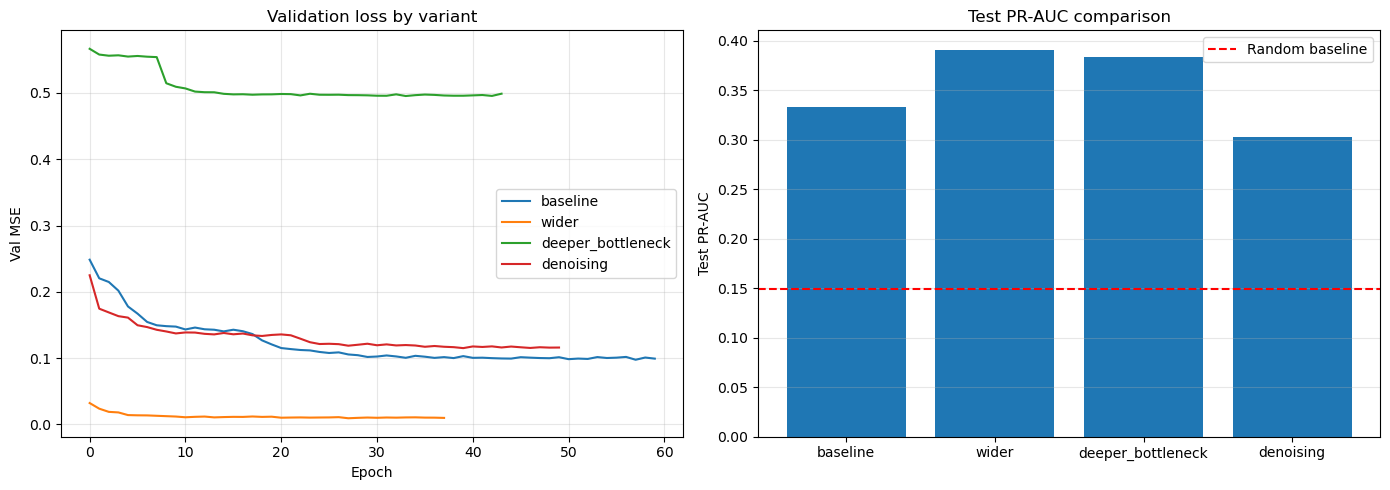

In [15]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for r in results:
    axes[0].plot(r['history']['val_loss'], label=r['name'])
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Val MSE')
axes[0].set_title('Validation loss by variant'); axes[0].legend(); axes[0].grid(alpha=0.3)

names = [r['name'] for r in results]
pr_aucs = [r['pr_auc'] for r in results]
axes[1].bar(names, pr_aucs)
axes[1].set_ylabel('Test PR-AUC'); axes[1].set_title('Test PR-AUC comparison')
axes[1].axhline(y=data['y_test'].mean(), linestyle='--', color='red', label='Random baseline')
axes[1].legend(); axes[1].grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('../figures/variant_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## Findings

Run the cell below for an auto-generated summary once all experiments complete.

In [16]:
# Auto-generate findings summary
best = max(results, key=lambda r: r["pr_auc"])
worst = min(results, key=lambda r: r["pr_auc"])
random_baseline = data["y_test"].mean()
best_name = best["name"]
best_dims = best["hidden_dims"]
best_prauc = best["pr_auc"]
best_improvement = best_prauc / random_baseline
best_f1 = best["f1"]
best_recall = best["recall"]
print("=" * 60)
print("FINDINGS SUMMARY")
print("=" * 60)
print(f"Best variant:  {best_name}  (hidden_dims={best_dims})")
print(f"  PR-AUC: {best_prauc:.4f}  ({best_improvement:.1f}x random baseline)")
print(f"  F1:     {best_f1:.4f}")
print(f"  Recall: {best_recall:.4f}")
print()
print(f"Random baseline (fraud rate): {random_baseline:.4f}")
print()
print("All variants ranked by PR-AUC:")
for r in sorted(results, key=lambda x: x["pr_auc"], reverse=True):
    r_name = r["name"]
    r_prauc = r["pr_auc"]
    r_f1 = r["f1"]
    print(f"  {r_name:25s}  PR-AUC={r_prauc:.4f}  F1={r_f1:.4f}")

FINDINGS SUMMARY
Best variant:  wider  (hidden_dims=[128, 64, 32])
  PR-AUC: 0.3911  (2.6x random baseline)
  F1:     0.3242
  Recall: 0.2485

Random baseline (fraud rate): 0.1496

All variants ranked by PR-AUC:
  wider                      PR-AUC=0.3911  F1=0.3242
  deeper_bottleneck          PR-AUC=0.3839  F1=0.3281
  baseline                   PR-AUC=0.3327  F1=0.2749
  denoising                  PR-AUC=0.3027  F1=0.2418
